#🛠️ Preparación de los Datos

###Extracción del archivo tratado

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("https://raw.githubusercontent.com/hq20d/challenge-telcomx-2/main/datos_tratados.csv")

df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [2]:
df = df.drop(columns=['CustomerID'])

In [3]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

In [4]:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


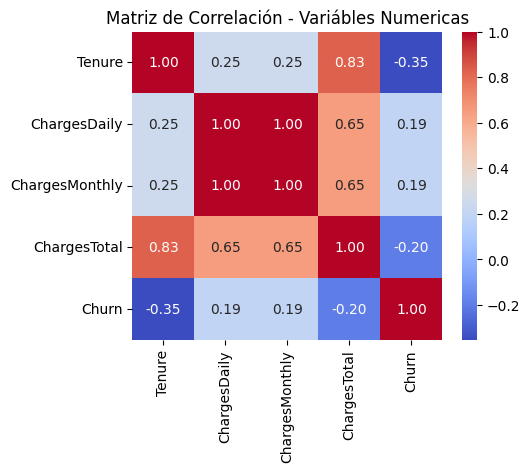

In [10]:
df_numeric = df.select_dtypes(include=["int64", "float64"])

df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variábles Numericas")
plt.show()

In [11]:
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

####Analisis por categoria

In [13]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

In [14]:
for col in categorical_cols:
    print(f"\n📌 Analisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [15]:
# Qui-cuadrado (Chi-Square Test)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Crea copia
df_rank = df.copy()

# Convertir Churn para binario
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df


,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [16]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")
categorical_cols

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [17]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [18]:
df_encoded["Churn"] = df_encoded["Churn"].map({"Yes": 1, "No": 0})

In [19]:
print(df_encoded.head())
print(df_encoded.info())

   Churn  Tenure  ChargesMonthly  Gender_Male  SeniorCitizen_Yes  Partner_Yes  \
0      0       9            65.6        False              False         True   
1      0       9            59.9         True              False        False   
2      1       4            73.9         True              False        False   
3      1      13            98.0         True               True         True   
4      1       3            83.9        False               True         True   

   Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0            True              True              False   
1           False              True               True   
2           False              True              False   
3           False              True              False   
4           False              True              False   

   InternetService_Fiber optic  ...  DeviceProtection_Yes  TechSupport_Yes  \
0                        False  ...                 False             True   
1       

In [20]:
print("Conteo de Churn:")
print(df_encoded["Churn"].value_counts())

Conteo de Churn:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [21]:
print("\nPorcentaje de Churn:")
print(df_encoded["Churn"].value_counts(normalize=True)*100)


Porcentaje de Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


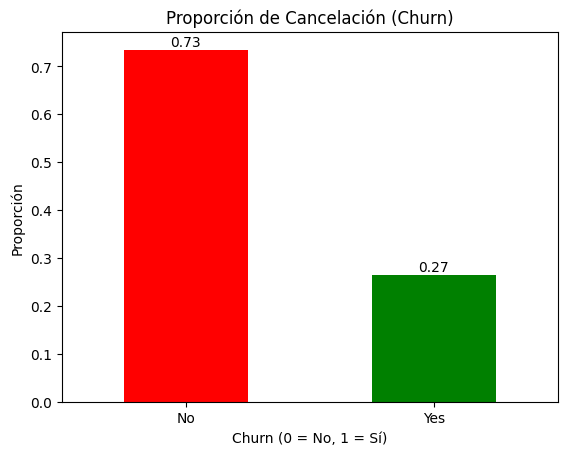

In [24]:
churn_counts = df["Churn"].value_counts(normalize=True)

ax = churn_counts.plot(kind="bar", color=["red", "green"])

plt.title("Proporción de Cancelación (Churn)")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Proporción")

plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.show()

#🎯 Correlación y Selección de Variables

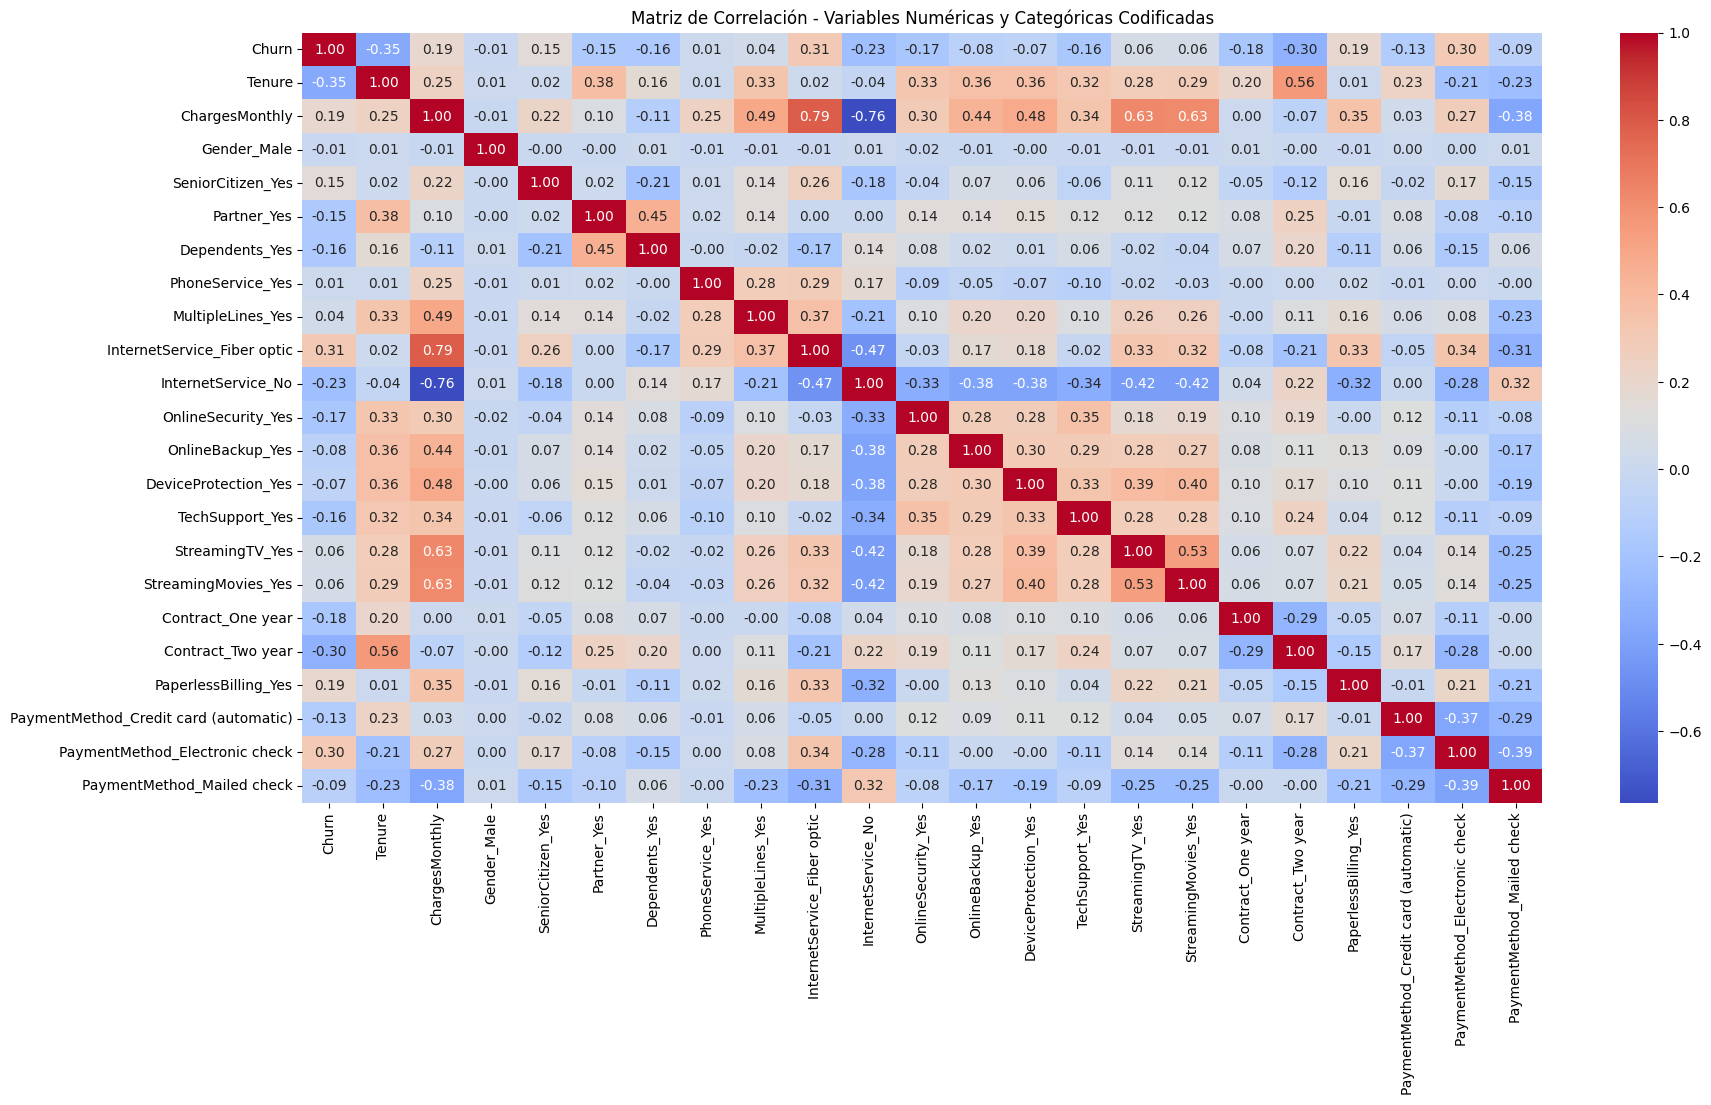

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt


num_cols = df_encoded.select_dtypes(include=["int64", "float64", "bool"]).columns

corr_matrix = df_encoded[num_cols].corr()


plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Variables Numéricas y Categóricas Codificadas")
plt.show()

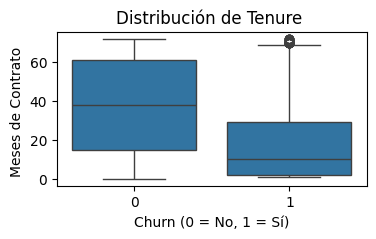

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,2))
sns.boxplot(x="Churn", y="Tenure", data=df_encoded)
plt.title("Distribución de Tenure ")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Meses de Contrato ")
plt.show()

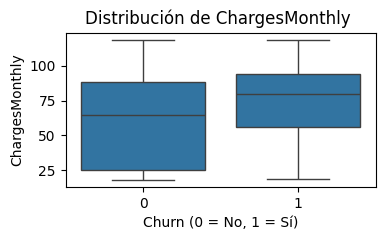

In [32]:

plt.figure(figsize=(4,2))
sns.boxplot(x="Churn", y="ChargesMonthly", data=df_encoded)
plt.title("Distribución de ChargesMonthly ")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("ChargesMonthly")
plt.show()

#🤖 Modelado Predictivo

In [33]:
from sklearn.model_selection import train_test_split


y = df_encoded["Churn"]


X = df_encoded.drop(columns=["Churn"])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


print(f"Tamaño X_train: {X_train.shape}")
print(f"Tamaño X_test: {X_test.shape}")
print(f"Tamaño y_train: {y_train.shape}")
print(f"Tamaño y_test: {y_test.shape}")

Tamaño X_train: (4930, 22)
Tamaño X_test: (2113, 22)
Tamaño y_train: (4930,)
Tamaño y_test: (2113,)


In [35]:
from sklearn.preprocessing import StandardScaler

num_cols = ["Tenure", "ChargesMonthly"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [36]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
# Función para calcular métricas
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print(f"Exactitud (Accuracy): {acc:.3f}")
    print(f"Precisión (Precision): {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print("\n")

    # Matriz de confusión
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusión - {model_name}")
    plt.show()


In [49]:
# Regresión Logística
y_pred_log = log_model.predict(X_train_scaled)  # entrenamiento
y_pred_log_test = log_model.predict(X_test_scaled)  # prueba

# Random Forest
y_pred_rf = rf_model.predict(X_train)  # entrenamiento
y_pred_rf_test = rf_model.predict(X_test)  # prueba


--- Regresión Logística (Train) ---
Exactitud (Accuracy): 0.808
Precisión (Precision): 0.666
Recall: 0.557
F1-score: 0.606




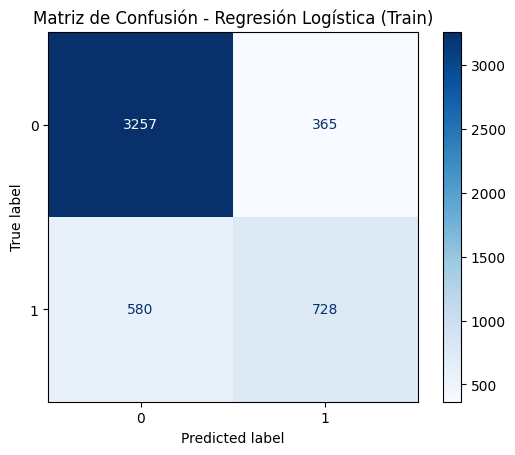

--- Random Forest (Train) ---
Exactitud (Accuracy): 0.997
Precisión (Precision): 0.996
Recall: 0.994
F1-score: 0.995




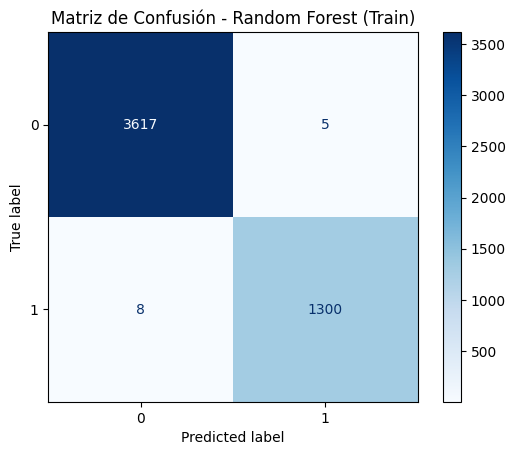

In [52]:
evaluate_model(y_train, y_pred_log, "Regresión Logística (Train)")
evaluate_model(y_train, y_pred_rf, "Random Forest (Train)")

--- Regresión Logística (Test) ---
Exactitud (Accuracy): 0.798
Precisión (Precision): 0.641
Recall: 0.542
F1-score: 0.587




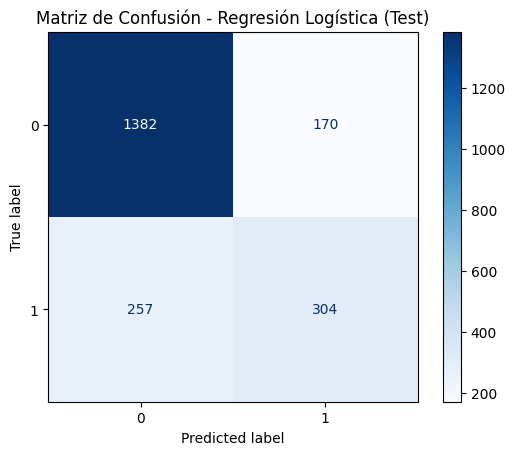

--- Random Forest (Test) ---
Exactitud (Accuracy): 0.785
Precisión (Precision): 0.623
Recall: 0.478
F1-score: 0.541




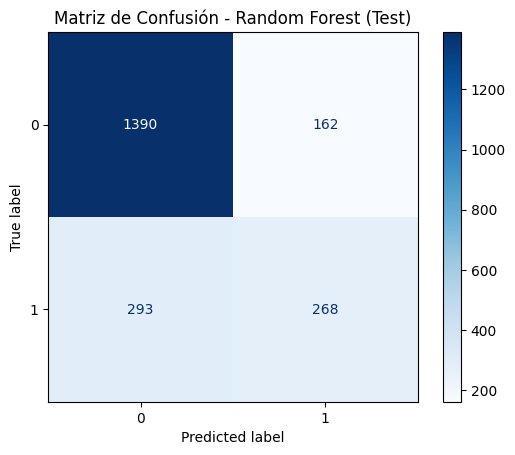

In [53]:
evaluate_model(y_test, y_pred_log_test, "Regresión Logística (Test)")
evaluate_model(y_test, y_pred_rf_test, "Random Forest (Test)")

#📋 Interpretación y Conclusiones

/tmp/ipykernel_194/89438311.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coeficiente", y="Variable", data=coef_sorted.head(10), palette="coolwarm")


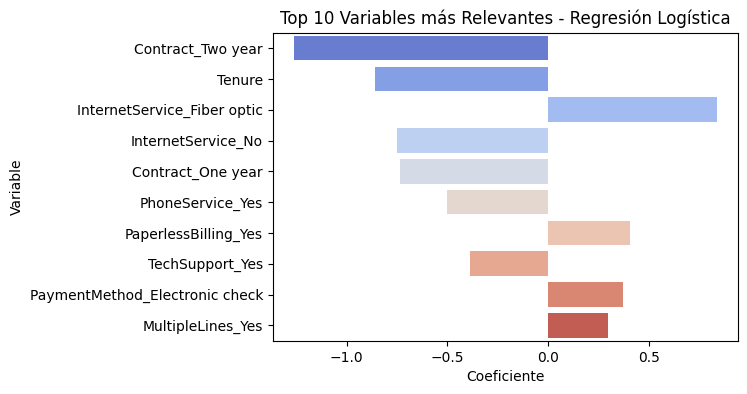

In [55]:
# Obtener coeficientes
coef = pd.DataFrame({
    "Variable": X_train_scaled.columns,
    "Coeficiente": log_model.coef_[0]
})

# Ordenar por valor absoluto
coef["AbsCoef"] = coef["Coeficiente"].abs()
coef_sorted = coef.sort_values(by="AbsCoef", ascending=False)

# Gráfico
plt.figure(figsize=(6,4))
sns.barplot(x="Coeficiente", y="Variable", data=coef_sorted.head(10), palette="coolwarm")
plt.title("Top 10 Variables más Relevantes - Regresión Logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable")
plt.show()

En este proyecto se desarrolló un análisis orientado a comprender y predecir la cancelación de clientes en la empresa Telecom X. Mediante un proceso que incluyó exploración de datos, preparación y limpieza de la información, así como la aplicación de modelos de machine learning, se logró identificar los factores más relevantes relacionados con el fenómeno de churn.

Los resultados obtenidos indican que variables como la antigüedad del cliente, el tipo de contrato, los cargos mensuales y determinadas características del servicio influyen de manera importante en la probabilidad de que un cliente decida cancelar. Asimismo, los modelos predictivos construidos permiten detectar con anticipación a los clientes con mayor riesgo de abandono.

Este tipo de análisis brinda a las empresas la posibilidad de tomar decisiones basadas en datos, facilitando el desarrollo de estrategias de retención más eficientes. De esta manera, es posible disminuir la pérdida de clientes y fortalecer la estabilidad y el crecimiento del negocio.